In [1]:
import sys
!{sys.executable} -m pip install tensorflow pandas scikit-learn -q

In [3]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ⚠️ Cambia el nombre al de tu CSV
df = pd.read_csv('df_total.csv', encoding='UTF-8')

# Convertimos etiquetas de texto a números: "deportes" → 0, "política" → 1, etc.
le = LabelEncoder()
df['label_num'] = le.fit_transform(df['Type'])
num_clases = len(le.classes_)

print('Categorías encontradas:', le.classes_)
print('Número de clases:', num_clases)
df.head()

Categorías encontradas: ['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']
Número de clases: 7


,url,news,Type,label_num
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra,3
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones,4
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas,0
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia,2
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra,3


In [4]:
# Parámetros
vocab_size    = 10000  # Solo las 10.000 palabras más comunes
max_length    = 200    # Todas las noticias tendrán 200 palabras
trunc_type    = 'post'
padding_type  = 'post'

# Tokenizador: aprende el vocabulario
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['news'])

# Texto → secuencia de números
sequences = tokenizer.texts_to_sequences(df['news'])

# Padding: todas las secuencias a la misma longitud (200)
padded = pad_sequences(sequences, maxlen=max_length,
                       padding=padding_type, truncating=trunc_type)

# Ejemplo visual
print('Noticia original:')
print(df['news'][0][:100])
print('\nComo secuencia de números:')
print(sequences[0][:20], '...')
print('\nCon padding (longitud fija 200):')
print(padded[0])

Noticia original:
Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sosten

Como secuencia de números:
[64, 5, 1574, 3, 208, 1, 664, 13, 5, 83, 122, 5, 197, 2, 142, 7, 45, 752, 2, 25] ...

Con padding (longitud fija 200):
[  64    5 1574    3  208    1  664   13    5   83  122    5  197    2
  142    7   45  752    2   25    4   46 1718 1925  454    6   18  140
 1095    6    3  142   24    3  841    1    8  310  355 1363 1364    6
    5   24   90   14 1002    2  194  122   73   90   14   49  138    2
   26    6    1   13 1925    5  464   19  140   18   24  992 1611  504
    6 7871   34  575 3764    4  439    2    9  673   12  212 1879    2
  620    3 1575    4  474    8    3 4755    2  384   19  447   14  464
 1271   16    3 2029    3  142  118 2762  440    8  429  949    2  780
  891    5 2276    1    6   26    6   12  633    4 2277 7872   24   18
   14  614    2  870   29    2  384    4 1046   18   14  614    2 3765
   11   76    2    9  38

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    padded, df['label_num'], test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_train.shape}')
print(f'Prueba:        {X_test.shape}')

Entrenamiento: (973, 200)
Prueba:        (244, 200)


In [6]:
model = tf.keras.Sequential([
    # 1. Embedding: cada palabra → vector de 16 números
    tf.keras.layers.Embedding(vocab_size, 16, input_length=max_length),

    # 2. GlobalAveragePooling: reduce (200, 16) → (16,)
    tf.keras.layers.GlobalAveragePooling1D(),

    # 3. Capa densa intermedia: aprende patrones
    tf.keras.layers.Dense(24, activation='relu'),

    # 4. Capa de salida: una neurona por categoría
    tf.keras.layers.Dense(num_clases, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/home/ciabd01/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1774365035.297538    9032 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=2
)

Epoch 1/10
31/31 - 1s - 22ms/step - accuracy: 0.2220 - loss: 1.9213 - val_accuracy: 0.3811 - val_loss: 1.8877
Epoch 2/10
31/31 - 0s - 3ms/step - accuracy: 0.3258 - loss: 1.8537 - val_accuracy: 0.2992 - val_loss: 1.8119
Epoch 3/10
31/31 - 0s - 3ms/step - accuracy: 0.2744 - loss: 1.7813 - val_accuracy: 0.2992 - val_loss: 1.7497
Epoch 4/10
31/31 - 0s - 4ms/step - accuracy: 0.2744 - loss: 1.7277 - val_accuracy: 0.2992 - val_loss: 1.7099
Epoch 5/10
31/31 - 0s - 3ms/step - accuracy: 0.2744 - loss: 1.6773 - val_accuracy: 0.2992 - val_loss: 1.6658
Epoch 6/10
31/31 - 0s - 3ms/step - accuracy: 0.2888 - loss: 1.6170 - val_accuracy: 0.3156 - val_loss: 1.6094
Epoch 7/10
31/31 - 0s - 3ms/step - accuracy: 0.3823 - loss: 1.5419 - val_accuracy: 0.3689 - val_loss: 1.5417
Epoch 8/10
31/31 - 0s - 3ms/step - accuracy: 0.4481 - loss: 1.4537 - val_accuracy: 0.4918 - val_loss: 1.4622
Epoch 9/10
31/31 - 0s - 3ms/step - accuracy: 0.5365 - loss: 1.3583 - val_accuracy: 0.5738 - val_loss: 1.3873
Epoch 10/10
31/31 

In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Precisión Deep Learning: {accuracy*100:.2f}%')
print(f'   Loss:                   {loss:.4f}')

Precisión Deep Learning: 16.39%
   Loss:                   1.9458


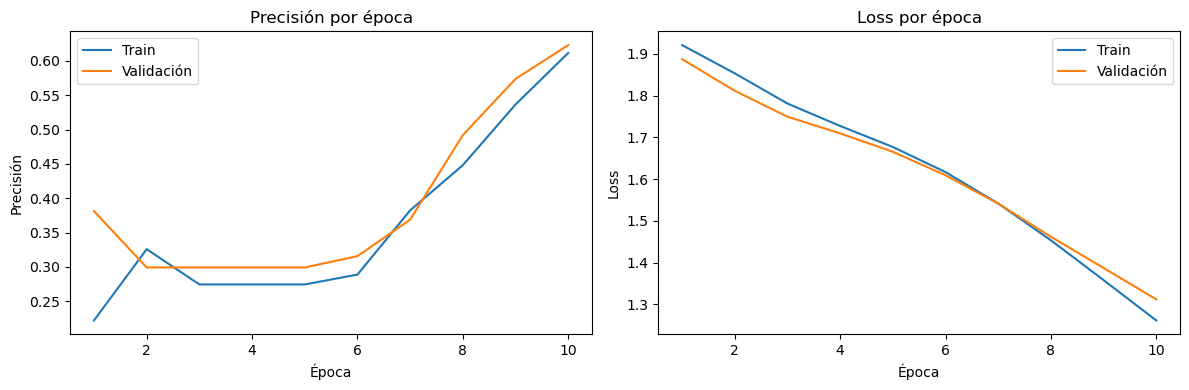

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, 11)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'],    label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validación')
plt.title('Precisión por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'],    label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
nueva_noticia = ["El perro ha comido pasto venenoso"]

secuencia_nueva = tokenizer.texts_to_sequences(nueva_noticia)
padded_nueva    = pad_sequences(secuencia_nueva, maxlen=max_length)

prediccion   = model.predict(padded_nueva, verbose=0)
clase_predicha = le.inverse_transform([tf.argmax(prediccion[0]).numpy()])

print(f'Noticia: {nueva_noticia[0]}')
print(f'Categoría predicha: {clase_predicha[0]}')
print(f'\nProbabilidades por categoría:')
for cat, prob in zip(le.classes_, prediccion[0]):
    print(f'  {cat:15s}: {prob*100:.1f}%')

Noticia: El perro ha comido pasto venenoso
Categoría predicha: Innovacion

Probabilidades por categoría:
  Alianzas       : 4.0%
  Innovacion     : 51.5%
  Macroeconomia  : 39.5%
  Otra           : 0.8%
  Regulaciones   : 2.0%
  Reputacion     : 0.0%
  Sostenibilidad : 2.3%
